In [1]:
!pip install pandas

In [2]:
import pandas as pd
import sqlite3
from sqlite3 import Error

In [3]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [4]:
query = """
SELECT datetime, uid
FROM pageviews
WHERE uid LIKE "user_%"
"""

df = pd.read_sql(query, connection)
df["date"] = pd.to_datetime(df["datetime"]).dt.date

new_df = df.groupby(["date"]).agg(**{"views": ("date", "count")})
new_df = new_df.reset_index()

new_df

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


<Axes: title={'center': 'Views per day'}, xlabel='date'>

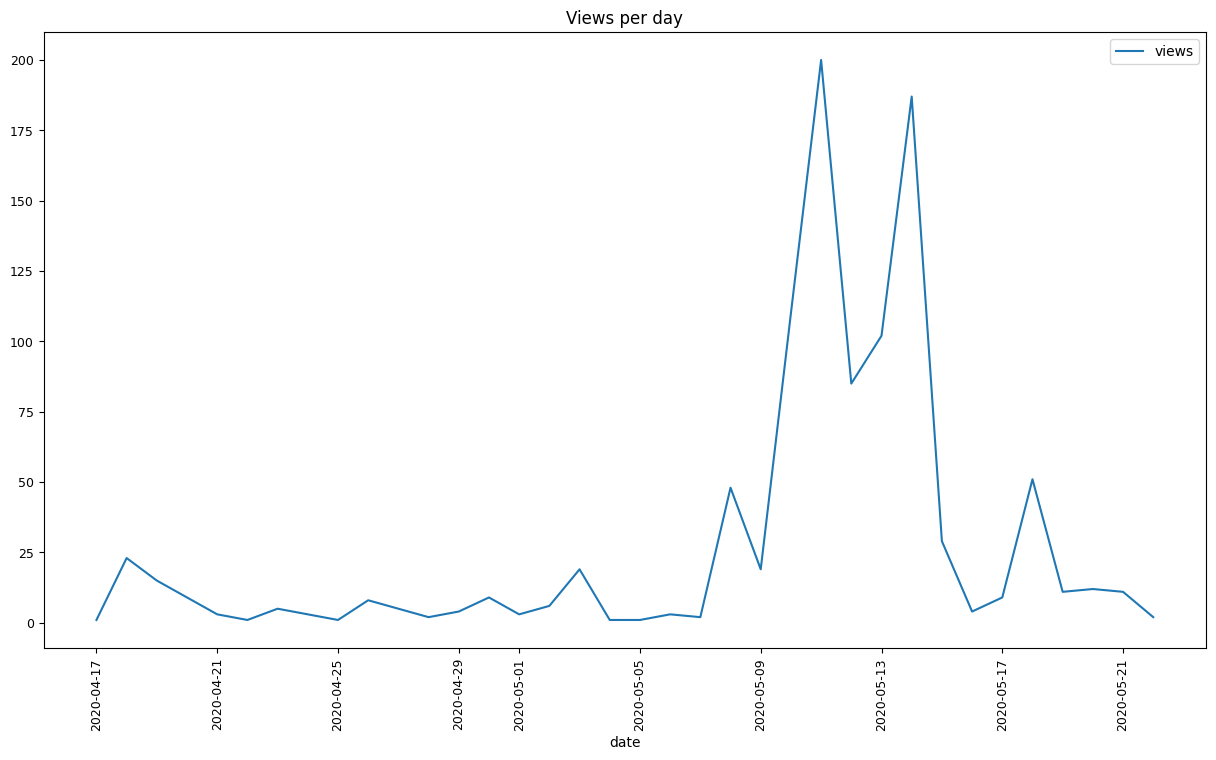

In [5]:
new_df.plot(x="date", fontsize=9, figsize=(15, 8), title="Views per day", rot=90)

In [6]:
connection.close()